In [ ]:
from IPython.display import display
import numpy as np
import pandas as pd

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
matches = pd.read_excel('results.xlsx')
penalty = pd.read_excel('shootouts.xlsx')

In [ ]:
unique_teams = list(set(matches['home_team'].unique()) | set(matches['away_team'].unique()))
len(unique_teams)

259

In [ ]:
sorted_unique_teams = sorted(unique_teams)
print(sorted_unique_teams)

['Afghanistan', 'Albania', 'Alderney', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Aymara', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Basque Country', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Biafra', 'Bolivia', 'Bonaire', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chameria', 'Chile', 'China PR', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'CuraÃ§ao', 'Cyprus', 'Czech Republic', 'DR Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Elba Island', 'England', 'Equatorial Guinea', 'Estonia', 'Eswatini', 'Ethiopia', 'Falkland Islands', 'Faroe Islands', 'Fiji', 'Finland', 'France', 'Fre

In [ ]:
replace_from = ['Czech Republic', 'DR Congo', 'Iran', 'Ivory Coast', 'South Korea', 'Turkey', 'Cape Verde', 'United States', 'CuraÃ§ao']
replace_to = ['Czechia', 'Congo DR', 'IR Iran', "Côte d'Ivoire", 'Korea Republic','Turkiye', 'Cabo Verde', 'USA', 'Curacao']

In [ ]:
matches['home_team'].replace(replace_from, replace_to, inplace=True)
matches['away_team'].replace(replace_from, replace_to, inplace=True)
matches['country'].replace(replace_from, replace_to, inplace=True)

/tmp/ipython-input-3014100219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['home_team'].replace(replace_from, replace_to, inplace=True)
/tmp/ipython-input-3014100219.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [ ]:
unique_teams = list(set(matches['home_team'].unique()) | set(matches['away_team'].unique()))
len(unique_teams)

259

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns
from scipy.stats import poisson
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
from IPython.display import display, HTML

In [ ]:
matches.head()

,date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral
0,2020-01-07,Barbados,Canada,1.0,4.0,Friendly,Irvine,USA,True
1,2020-01-09,Moldova,Sweden,0.0,1.0,Friendly,Doha,Qatar,True
2,2020-01-10,Barbados,Canada,1.0,4.0,Friendly,Irvine,USA,True
3,2020-01-12,Kosovo,Sweden,0.0,1.0,Friendly,Doha,Qatar,True
4,2020-01-15,Canada,Iceland,0.0,1.0,Friendly,Irvine,USA,True


In [ ]:
matches = matches.astype({'date':'datetime64[ns]'})

In [ ]:

home = matches[['home_team', 'home_goals']].rename(columns={'home_team':'team', 'home_goals':'score'})
away = matches[['away_team', 'away_goals']].rename(columns={'away_team':'team', 'away_goals':'score'})
# merge it into one
team_score = home._append(away).reset_index(drop=True)
# make an aggregation of the the score column group by the team
country_info = team_score.groupby('team')['score'].agg(['sum','count','mean']).reset_index()
country_info = country_info.rename(columns={'sum':'nb_goals', 'count':'nb_matches', 'mean':'goal_avg'})

del home, away

In [ ]:
means = matches[['home_goals','away_goals']].mean()
means

,0
home_goals,1.599529
away_goals,1.108774


/tmp/ipython-input-3672986609.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  poisson_pred = np.column_stack([[poisson.pmf(k, means[j]) for k in range(10)] for j in range(2)])


ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (11).

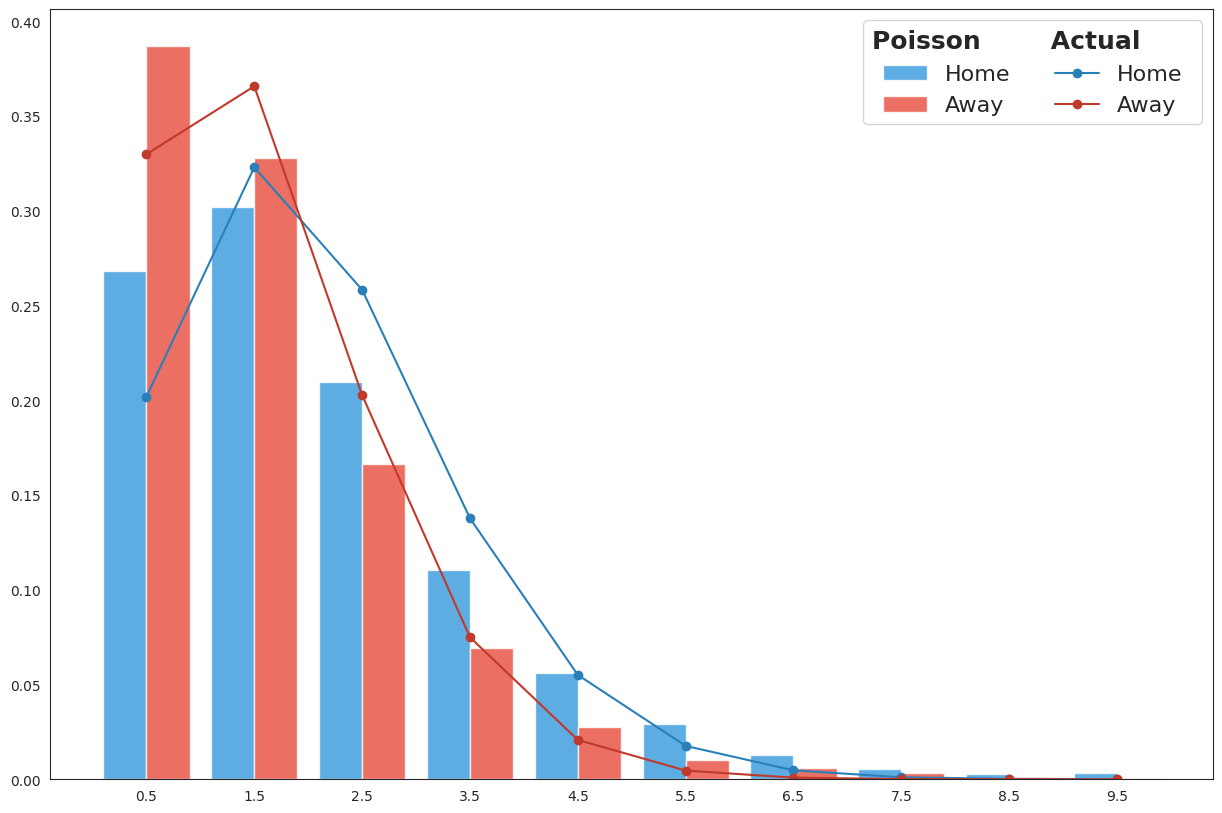

In [ ]:
plt.figure(figsize=(15,10))
sns.set_style("white")
# construct Poisson  for each mean goals value
poisson_pred = np.column_stack([[poisson.pmf(k, means[j]) for k in range(10)] for j in range(2)])
# plot histogram of actual goals
plt.hist(matches[['home_goals', 'away_goals']].values, range(11), alpha=0.8,
         label=['Home', 'Away'],density=True, color=["#3498db", "#e74c3c"])

# add lines for the Poisson distributions
pois1, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred[:,0],
                  linestyle='-', marker='o',label="Home", color = '#2980b9')
pois2, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred[:,1],
                  linestyle='-', marker='o',label="Away", color = '#c0392b')

leg=plt.legend(loc='upper right', fontsize=16, ncol=2)
leg.set_title("Poisson        Actual      ", prop = {'size':'18', 'weight':'bold'})

plt.xticks([i-0.5 for i in range(1,11)],[i for i in range(11)])
plt.xlabel("Goals per Match",size=18)
plt.ylabel("Proportion of Matches",size=18)
plt.title("Number of Goals per Match",size=20,fontweight='bold')
plt.show()

ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (11).

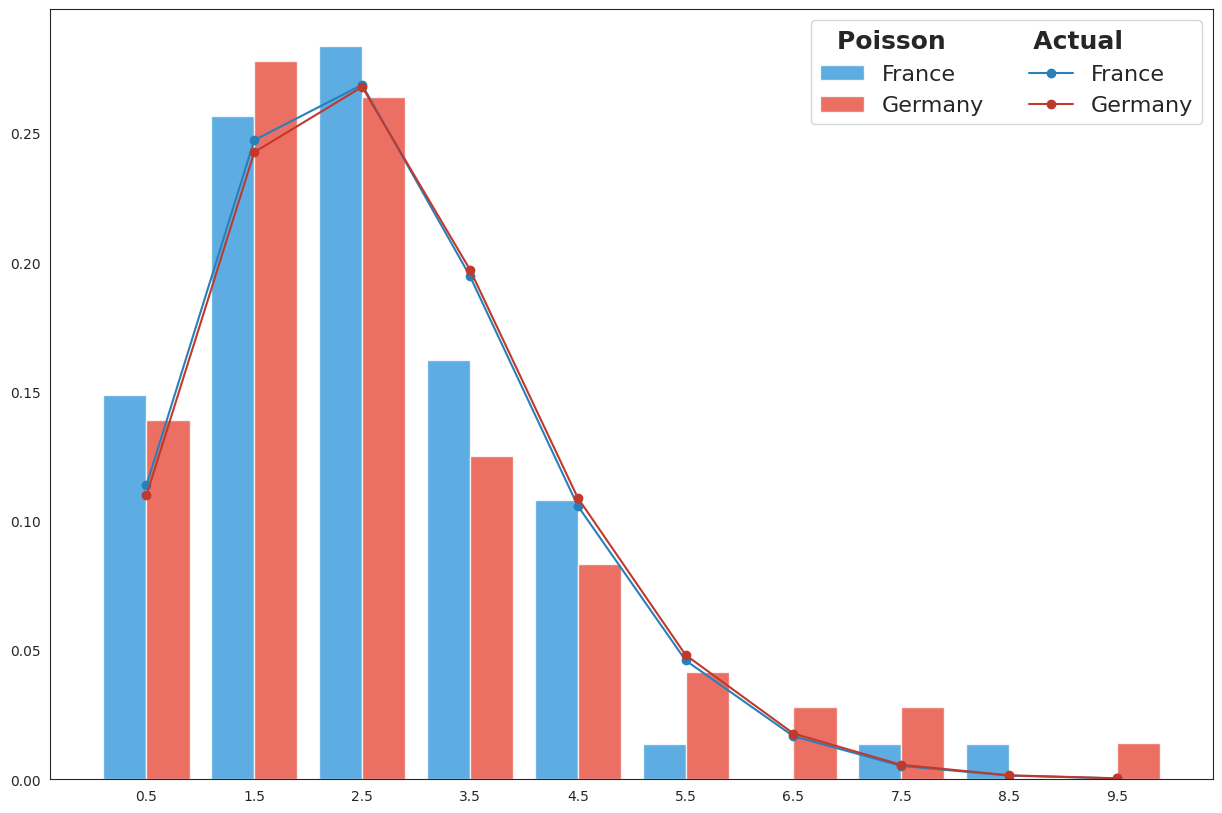

In [ ]:
plt.figure(figsize=(15,10))
sns.set_style("white")
team1, team2 = "France", "Germany"
matches_t1 = team_score[team_score['team'] == team1]
matches_t2 = team_score[team_score['team'] == team2]

mean_t1 = matches_t1['score'].mean()
mean_t2 = matches_t2['score'].mean()

# construct Poisson  for each mean goals value
poisson_pred_t1 = [poisson.pmf(k, mean_t1) for k in range(10)]
poisson_pred_t2 = [poisson.pmf(k, mean_t2) for k in range(10)]

# plot histogram of actual goals
plt.hist([matches_t1['score'].values, matches_t2['score'].values], range(11), alpha=0.8,
         label=[team1, team2],density=True, color=["#3498db", "#e74c3c"])

# add lines for the Poisson distributions
pois1, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred_t1,
                  linestyle='-', marker='o',label=team1, color = '#2980b9')
pois2, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred_t2,
                  linestyle='-', marker='o',label=team2, color = '#c0392b')

leg=plt.legend(loc='upper right', fontsize=16, ncol=2)
leg.set_title("Poisson          Actual      ", prop = {'size':'18', 'weight':'bold'})

plt.xticks([i-0.5 for i in range(1,11)],[i for i in range(11)])
plt.xlabel("Goals per Match",size=18)
plt.ylabel("Proportion of Matches",size=18)
plt.title("Number of Goals per Match",size=20,fontweight='bold')
plt.show

In [ ]:
matches['tournament'].unique()

array(['Friendly', 'UEFA Nations League', 'FIFA World Cup qualification',
       'UEFA Euro qualification', 'African Cup of Nations qualification',
       'Baltic Cup', 'CONCACAF Nations League', 'Kirin Challenge Cup',
       'UEFA Euro', 'Copa AmÃ©rica', 'Arab Cup qualification',
       'Gold Cup qualification', 'COSAFA Cup', 'Gold Cup',
       'Three Nations Cup', 'SAFF Cup', 'AFC Asian Cup qualification',
       'Mahinda Rajapaksa Cup', 'Arab Cup', 'AFF Championship',
       'African Cup of Nations', 'Navruz Cup', 'Muratti Vase',
       'CONIFA Africa Football Cup', 'CONMEBOLâ€“UEFA Cup of Champions',
       'Kirin Cup', 'CONIFA South America Football Cup',
       'EAFF Championship', "MSG Prime Minister's Cup", "King's Cup",
       'Jordan International Tournament',
       'AFF Championship qualification', 'FIFA World Cup', 'Gulf Cup',
       'Tri Nation Tournament', 'CAFA Nations Cup',
       'Mauritius Four Nations Cup',
       'CONIFA World Football Cup qualification', 'Island G

In [ ]:
matches['id'] = range(1, len(matches) + 1)

In [ ]:
def weight_from_tournament(tournament):
    priority = {
        'FIFA World Cup': 1,
        'UEFA Euro': 2,
        'Copa AmÃ©rica': 2,
        'African Cup of Nations': 2,
        'AFC Asian Cup': 2,
        'Gold Cup': 2,
        'Oceania Nations Cup': 2,
        'CAFA Nations Cup': 3,
        'EAFF Championship': 3,
        'WAFF Championship': 3,
        'COSAFA Cup': 3,
        'SAFF Cup': 3,
        'AFF Championship': 3,
        'West African Cup': 3,
        'CECAFA Cup': 3,
        'Gulf Cup': 3,
        'Arab Cup': 3,
        'CAFA Nations Cup': 3,
        'FIFA World Cup qualification': 4,
        'CONCACAF Nations League': 4,
        'UEFA Nations League': 4,
        'Africa Cup of Nations qualification': 5,
        'Gold Cup qualification': 5,
        'Oceania Nations Cup qualification': 5,
        'UEFA Euro qualification': 5,
        'CONCACAF Nations League qualification': 6,
        'AFF Championship qualification': 6,
        'COSAFA Cup qualification': 6,
        'Arab Cup qualification': 6
    }

    if tournament in priority:
        return priority[tournament]
    elif 'Friendly' in tournament:
        return 8
    else:
        return 7

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Filter matches based on the given criteria
matches_filtered = matches[(matches['id'] >= 0) & (matches['id'] <= 5518)].copy()

# Apply the weighting function to create the 'weight' column
matches_filtered['weight'] = matches_filtered['tournament'].apply(weight_from_tournament)

matches_filtered['weight'] = pd.to_numeric(matches_filtered['weight'], errors='coerce')

# Replace 0 with a very small positive value (statsmodels rejects 0 weight)
matches_filtered.loc[matches_filtered['weight'] == 0, 'weight'] = np.nan

# Now invert
matches_filtered['weight'] = 1 / matches_filtered['weight']

# Clean again
matches_filtered['weight'] = pd.to_numeric(matches_filtered['weight'], errors='coerce')

# Drop invalid values before creating model data
matches_filtered = matches_filtered.dropna(subset=['weight'])
matches_filtered = matches_filtered[matches_filtered['weight'] > 0]


# Create model data
matches_model_data = pd.concat([
    matches_filtered[['home_team', 'away_team', 'home_goals', 'neutral', 'weight']].rename(
        columns={'home_team': 'team', 'away_team': 'opponent', 'home_goals': 'goals'}),
    matches_filtered[['away_team', 'home_team', 'away_goals', 'neutral', 'weight']].rename(
        columns={'away_team': 'team', 'home_team': 'opponent', 'away_goals': 'goals'})
])


# Remove rows with invalid weights
invalid_values = matches_model_data['weight'].isnull() | np.isinf(matches_model_data['weight'])
matches_model_data = matches_model_data[~invalid_values]

poisson_model = smf.glm(
    formula="goals ~ team + opponent",
    data=matches_model_data,
    family=sm.families.Poisson()
).fit_regularized(alpha=1e-4)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


In [ ]:
print(matches_model_data['weight'].describe())
print(matches_model_data['weight'].unique()[:20])
print(matches_model_data['weight'].isnull().sum(), "nulls")
print((matches_model_data['weight'] == 0).sum(), "zeros")
print((matches_model_data['weight'] < 0).sum(), "negative")
print(np.isinf(matches_model_data['weight']).sum(), "inf")


NameError: name 'matches_model_data' is not defined

In [ ]:
def get_proba_match(foot_model, team1, team2, neutral=False, max_goals=10):
    # Get the average goal for each team
    t1_goals_avg = foot_model.predict(pd.DataFrame(data={'team': team1, 'opponent': team2}, index=[1])).values[0]
    t2_goals_avg = foot_model.predict(pd.DataFrame(data={'team': team2, 'opponent': team1}, index=[1])).values[0]

    # Get probability of all possible score for each team
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [t1_goals_avg, t2_goals_avg]]

    # Do the product of the 2 vectors to get the matrix of the match
    match = np.outer(np.array(team_pred[0]), np.array(team_pred[1]))

    # Get the proba for each possible outcome
    t1_wins = np.sum(np.tril(match, -1))
    draw = np.sum(np.diag(match))
    t2_wins = np.sum(np.triu(match, 1))
    result_proba = [t1_wins, draw, t2_wins]

    # Adjust the proba to sum to one
    result_proba =  np.array(result_proba)/ np.array(result_proba).sum(axis=0,keepdims=1)
    team_pred[0] = np.array(team_pred[0])/np.array(team_pred[0]).sum(axis=0,keepdims=1)
    team_pred[1] = np.array(team_pred[1])/np.array(team_pred[1]).sum(axis=0,keepdims=1)
    return result_proba, [np.array(team_pred[0]), np.array(team_pred[1])]

In [ ]:
def get_match_result(foot_model, team1, team2, elimination=False, neutral=False, max_draw=50, max_goals=10):
    # Get the proba
    proba, score_proba = get_proba_match(foot_model, team1, team2,neutral, max_goals)

    # Get the result, if it's an elimination game we have to be sure the result is not draw
    results = pd.Series([np.random.choice([team1, 'draw', team2], p=proba) for i in range(0,max_draw)]).value_counts()
    result = results.index[0] if not elimination or (elimination and results.index[0] != 'draw') else results.index[1]

    # If the result is not a draw game then we calculate the score of the winner from 1 to the max_goals
    # and the score of the looser from 0 to the score of the winner
    if (result != 'draw'):
        i_win, i_loose = (0,1) if result == team1 else (1,0)
        score_proba[i_win] = score_proba[i_win][1:]/score_proba[i_win][1:].sum(axis=0,keepdims=1)
        winner_score = pd.Series([np.random.choice(range(1, max_goals+1), p=score_proba[i_win]) for i in range(0,max_draw)]).value_counts().index[0]
        score_proba[i_loose] = score_proba[i_loose][:winner_score]/score_proba[i_loose][:winner_score].sum(axis=0,keepdims=1)
        looser_score = pd.Series([np.random.choice(range(0, winner_score), p=score_proba[i_loose]) for i in range(0,max_draw)]).value_counts().index[0]
        score = [winner_score, looser_score]
    # If it's a draw then we calculate a score and repeat it twice
    else:
        score = np.repeat(pd.Series([np.random.choice(range(0, max_goals+1), p=score_proba[0]) for i in range(0,max_draw)]).value_counts().index[0],2)
    looser = team2 if result == team1 else team1 if result != 'draw' else 'draw'
    return result, looser, score

In [ ]:
print(get_match_result(poisson_model, 'Argentina', 'Germany', neutral=True))
print(get_match_result(poisson_model, 'Argentina', 'Peru', neutral=False))
print(get_match_result(poisson_model, 'India', 'Argentina', neutral=False))

(np.str_('Argentina'), 'Germany', [np.int64(1), np.int64(0)])
(np.str_('Argentina'), 'Peru', [np.int64(2), np.int64(0)])
(np.str_('Argentina'), 'India', [np.int64(4), np.int64(0)])


In [ ]:
groupA = ['Morocco', 'Mali','Zambia','Comoros']
groupB = ['Egypt', 'South Africa', 'Angola', 'Zimbabwe']
groupC = ['Nigeria', 'Tunisia', 'Uganda', 'Tanzania']
groupD = ['Senegal', 'Congo DR', 'Benin', 'Botswana']
groupE = ['Algeria', 'Burkina Faso', 'Equatorial Guinea', 'Sudan']
groupF = ["Côte d'Ivoire", 'Cameroon', 'Gabon', 'Mozambique']
groups = [groupA, groupB, groupC, groupD, groupE, groupF]

In [ ]:
import pandas as pd
import itertools

def get_group_result(foot_model, group,neutral=(team1 != "Germany" and team2 != "Germany")):
    ranking = pd.DataFrame({'points': [0, 0, 0, 0], 'diff': [0, 0, 0, 0], 'goals': [0, 0, 0, 0]}, index=group)
    match_results = []  # List to store results of individual matches

    for team1, team2 in itertools.combinations(group, 2):
        result, looser, score = get_match_result(foot_model, team1, team2)
        match_result = {
            'team1': team1,
            'team2': team2,
            'score': f"{score[0]} - {score[1]}"
        }

        if result == 'draw':
            ranking.loc[[team1, team2], 'points'] += 1
            ranking.loc[[team1, team2], 'goals'] += score[0]
            match_result['result'] = 'Draw'
        else:
            ranking.loc[result, 'points'] += 3
            ranking.loc[result, 'goals'] += score[0]
            ranking.loc[looser, 'goals'] += score[1]
            ranking.loc[result, 'diff'] += score[0] - score[1]
            ranking.loc[looser, 'diff'] -= score[0] - score[1]
            match_result['result'] = f"{result} wins"

        match_results.append(match_result)  # Append match results to the list

    # Convert list of match results to a DataFrame for easier viewing
    matches_df = pd.DataFrame(match_results)
    sorted_ranking = ranking.sort_values(by=['points', 'diff', 'goals'], ascending=False)

    return sorted_ranking, matches_df  # Return both standings and match resu
# Example usage
groups_ranking = []
match_details = []

for group in groups:
    ranking, matches = get_group_result(poisson_model, group)
    groups_ranking.append(ranking)
    match_details.append(matches)

# Display results
for group_rank, matches in zip(groups_ranking, match_details):
    display(group_rank)
    display(matches)

,points,diff,goals
Morocco,9,5,5
Mali,6,2,3
Zambia,3,-2,1
Comoros,0,-5,0


,team1,team2,score,result
0,Morocco,Mali,1 - 0,Morocco wins
1,Morocco,Zambia,2 - 0,Morocco wins
2,Morocco,Comoros,2 - 0,Morocco wins
3,Mali,Zambia,1 - 0,Mali wins
4,Mali,Comoros,2 - 0,Mali wins
5,Zambia,Comoros,1 - 0,Zambia wins


,points,diff,goals
Egypt,9,3,3
South Africa,4,0,3
Angola,4,0,3
Zimbabwe,0,-3,0


,team1,team2,score,result
0,Egypt,South Africa,1 - 0,Egypt wins
1,Egypt,Angola,1 - 0,Egypt wins
2,Egypt,Zimbabwe,1 - 0,Egypt wins
3,South Africa,Angola,2 - 2,Draw
4,South Africa,Zimbabwe,1 - 0,South Africa wins
5,Angola,Zimbabwe,1 - 0,Angola wins


,points,diff,goals
Tunisia,9,3,3
Nigeria,6,2,3
Tanzania,1,-2,0
Uganda,1,-3,0


...

,team1,team2,score,result
0,Senegal,Congo DR,1 - 0,Senegal wins
1,Senegal,Benin,2 - 0,Senegal wins
2,Senegal,Botswana,2 - 0,Senegal wins
3,Congo DR,Benin,1 - 0,Congo DR wins
4,Congo DR,Botswana,1 - 0,Congo DR wins
5,Benin,Botswana,2 - 1,Benin wins


,points,diff,goals
Algeria,9,5,5
Equatorial Guinea,4,-1,1
Burkina Faso,2,-1,1
Sudan,1,-3,1


,team1,team2,score,result
0,Algeria,Burkina Faso,1 - 0,Algeria wins
1,Algeria,Equatorial Guinea,2 - 0,Algeria wins
2,Algeria,Sudan,2 - 0,Algeria wins
3,Burkina Faso,Equatorial Guinea,0 - 0,Draw
4,Burkina Faso,Sudan,1 - 1,Draw
5,Equatorial Guinea,Sudan,1 - 0,Equatorial Guinea wins


,points,diff,goals
Côte d'Ivoire,9,4,4
Cameroon,6,0,2
Gabon,3,-1,1
Mozambique,0,-3,0


,team1,team2,score,result
0,Côte d'Ivoire,Cameroon,2 - 0,Côte d'Ivoire wins
1,Côte d'Ivoire,Gabon,1 - 0,Côte d'Ivoire wins
2,Côte d'Ivoire,Mozambique,1 - 0,Côte d'Ivoire wins
3,Cameroon,Gabon,1 - 0,Cameroon wins
4,Cameroon,Mozambique,1 - 0,Cameroon wins
5,Gabon,Mozambique,1 - 0,Gabon wins


# Qualified Teams
<h2> Group A <br> </h2>
1. Morocco <br>
2. Mali <br>
3. Zambia <br>

<h2> Group B <br> </h2>
1. Egypt <br>
2. South Africa <br>
3. Angola <br>

<h2> Group C <br> </h2>
1. Tunisia <br>
2. Nigeria <br>

<h2> Group D <br> </h2>
1. Senegal <br>
2. Congo DR <br>
3. Benin <br>

<h2> Group E <br> </h2>
1. Algeria <br>
2. Equatorial Guinea <br>

<h2> Group F <br> </h2>
1. Cote D'Ivoire <br>
2. Cameroon <br>
3. Gabon <br>


<h2>Ranking of 3rd Place teams<br> </h2>
Angola(B)<br>
Zambia(A)<br>
Benin(D)<br>
Gabon(F)<br>
_________<br>
Tanzania(C)<br>
Burkina Faso(E)<br>
Combination of Matches: ABDF
A1 vs D3, B1 vs A3, C1 vs B3, D1 vs F3


In [ ]:
def get_final_result(foot_model, groups_result):
    octo_finals = []
    quarter_finals = []
    semi_finals = []

    # SIMULATE OCTO FINALS
    octo_finals.append(get_match_result(foot_model, groups_result[0].index[1], groups_result[2].index[1], elimination=True, neutral=True))
    octo_finals.append(get_match_result(foot_model, groups_result[3].index[0], groups_result[5].index[2], elimination=True, neutral=True))
    octo_finals.append(get_match_result(foot_model, groups_result[1].index[0], groups_result[0].index[2], elimination=True, neutral=True))
    octo_finals.append(get_match_result(foot_model, groups_result[5].index[0], groups_result[4].index[1], elimination=True, neutral=True))
    octo_finals.append(get_match_result(foot_model, groups_result[1].index[1], groups_result[5].index[1], elimination=True, neutral=True))
    octo_finals.append(get_match_result(foot_model, groups_result[0].index[0], groups_result[3].index[2], elimination=True, neutral=False))
    octo_finals.append(get_match_result(foot_model, groups_result[4].index[0], groups_result[3].index[1], elimination=True, neutral=True))
    octo_finals.append(get_match_result(foot_model, groups_result[2].index[0], groups_result[1].index[2], elimination=True, neutral=True))

    # SIMULATE QUARTER FINALS
    quarter_finals.append(get_match_result(foot_model, octo_finals[4][0], octo_finals[5][0], elimination=True, neutral=(team1 != "Morocco" and team2 != "Morocco")))
    quarter_finals.append(get_match_result(foot_model, octo_finals[6][0], octo_finals[7][0], elimination=True, neutral=True))
    quarter_finals.append(get_match_result(foot_model, octo_finals[0][0], octo_finals[1][0], elimination=True, neutral=True))
    quarter_finals.append(get_match_result(foot_model, octo_finals[2][0], octo_finals[3][0], elimination=True, neutral=True))

    # SIMULATE SEMI FINALS
    semi_finals.append(get_match_result(foot_model, quarter_finals[2][0], quarter_finals[3][0], elimination=True, neutral=True))
    semi_finals.append(get_match_result(foot_model, quarter_finals[0][0], quarter_finals[1][0], elimination=True, neutral=(team1 != "Morocco" and team2 != "Morocco")))

    # SIMULATE FINAL
    final = get_match_result(foot_model, semi_finals[0][0], semi_finals[1][0], elimination=True,  neutral=(team1 != "Morocco" and team2 != "Morocco"))

    return octo_finals, quarter_finals, semi_finals, final


In [ ]:
octo_finals, quarter_finals, semi_finals, final = get_final_result(poisson_model, groups_ranking)

In [ ]:
octo_finals

[(np.str_('Mali'), 'Nigeria', [np.int64(1), np.int64(0)]),
 (np.str_('Senegal'), 'Gabon', [np.int64(2), np.int64(0)]),
 (np.str_('Egypt'), 'Zambia', [np.int64(2), np.int64(0)]),
 (np.str_("Côte d'Ivoire"), 'Equatorial Guinea', [np.int64(1), np.int64(0)]),
 (np.str_('Cameroon'), 'South Africa', [np.int64(1), np.int64(0)]),
 (np.str_('Morocco'), 'Benin', [np.int64(2), np.int64(0)]),
 (np.str_('Algeria'), 'Congo DR', [np.int64(2), np.int64(1)]),
 (np.str_('Tunisia'), 'Angola', [np.int64(1), np.int64(0)])]

In [ ]:
quarter_finals

[(np.str_('Morocco'), np.str_('Cameroon'), [np.int64(1), np.int64(0)]),
 (np.str_('Algeria'), np.str_('Tunisia'), [np.int64(1), np.int64(0)]),
 (np.str_('Mali'), np.str_('Senegal'), [np.int64(1), np.int64(0)]),
 (np.str_("Côte d'Ivoire"), np.str_('Egypt'), [np.int64(1), np.int64(0)])]

In [ ]:
semi_finals

[(np.str_("Côte d'Ivoire"), np.str_('Mali'), [np.int64(1), np.int64(0)]),
 (np.str_('Morocco'), np.str_('Algeria'), [np.int64(1), np.int64(0)])]

In [ ]:
final

(np.str_('Morocco'), np.str_("Côte d'Ivoire"), [np.int64(1), np.int64(0)])